In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [7]:
def euler(f, x, y, h):
    return y + h * f(x, y)

def midpoint(f, x, y, h):
    k1 = h * f(x, y)
    return y + h * f(x + h / 2, y + k1 / 2)

def solve_ode(method, rhs, initial, time_vals, step):
    sol = initial.copy()
    solutions = np.zeros((len(time_vals), len(initial)))
    for idx in range(len(time_vals)):
        solutions[idx, :] = sol
        sol = method(rhs, time_vals[idx], sol, step)
    return solutions

## Question 1

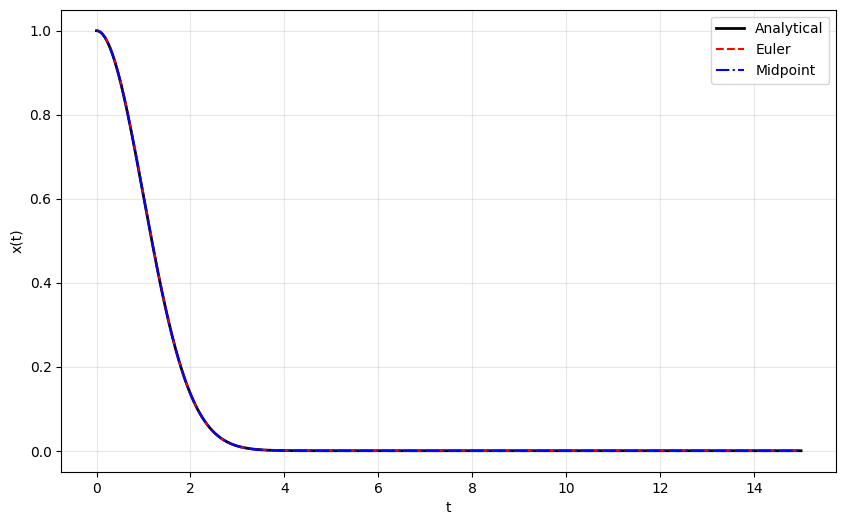

In [3]:
def rhs_q1(t, x):
    return -t * x

step_size = 0.01
t_start = 0.0
t_end = 15.0
init_val = np.array([1.0])

time_grid = np.arange(t_start, t_end + step_size, step_size)

sol_euler = solve_ode(euler, rhs_q1, init_val, time_grid, step_size)
sol_midpt = solve_ode(midpoint, rhs_q1, init_val, time_grid, step_size)
analytical = np.exp(-time_grid**2 / 2)

plt.figure(figsize=(10, 6))
plt.plot(time_grid, analytical, 'k-', linewidth=2, label='Analytical')
plt.plot(time_grid, sol_euler[:, 0], 'r--', label='Euler')
plt.plot(time_grid, sol_midpt[:, 0], 'b-.', label='Midpoint')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

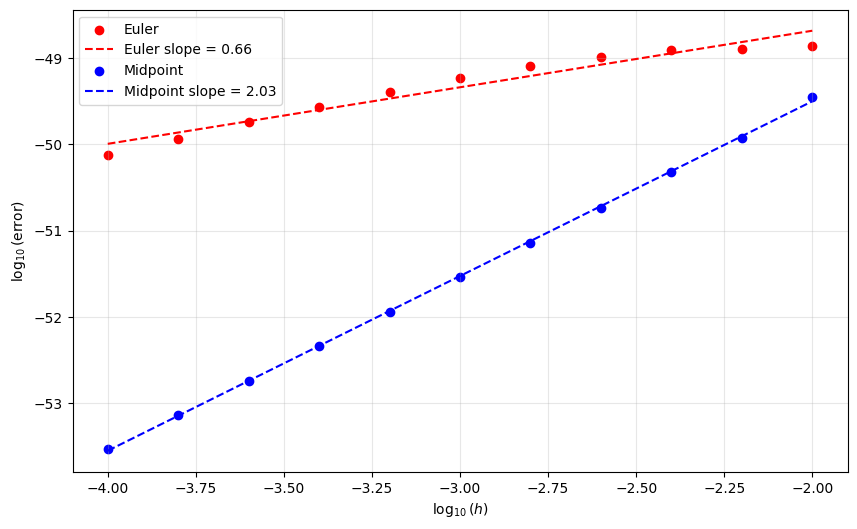

In [4]:
n_range = np.arange(-4.0, -1.8, 0.2)
step_sizes = 10.0 ** n_range

err_euler = []
err_midpt = []

for h in step_sizes:
    t_vals = np.arange(t_start, t_end + h, h)
    y_euler = solve_ode(euler, rhs_q1, init_val, t_vals, h)
    y_midpt = solve_ode(midpoint, rhs_q1, init_val, t_vals, h)
    exact_final = np.exp(-t_vals[-1]**2 / 2)
    err_euler.append(abs(y_euler[-1, 0] - exact_final))
    err_midpt.append(abs(y_midpt[-1, 0] - exact_final))

err_euler = np.array(err_euler)
err_midpt = np.array(err_midpt)

log_steps = np.log10(step_sizes)
log_err_e = np.log10(err_euler)
log_err_m = np.log10(err_midpt)

def fit_line(x, a, b):
    return a * x + b

fit_e, _ = curve_fit(fit_line, log_steps, log_err_e)
fit_m, _ = curve_fit(fit_line, log_steps, log_err_m)

plt.figure(figsize=(10, 6))
plt.scatter(log_steps, log_err_e, label="Euler", color='red')
plt.plot(log_steps, fit_line(log_steps, *fit_e), 'r--', label=f"Euler slope = {fit_e[0]:.2f}")
plt.scatter(log_steps, log_err_m, label="Midpoint", color='blue')
plt.plot(log_steps, fit_line(log_steps, *fit_m), 'b--', label=f"Midpoint slope = {fit_m[0]:.2f}")
plt.xlabel(r'$\log_{10}(h)$')
plt.ylabel(r'$\log_{10}$(error)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Question 2

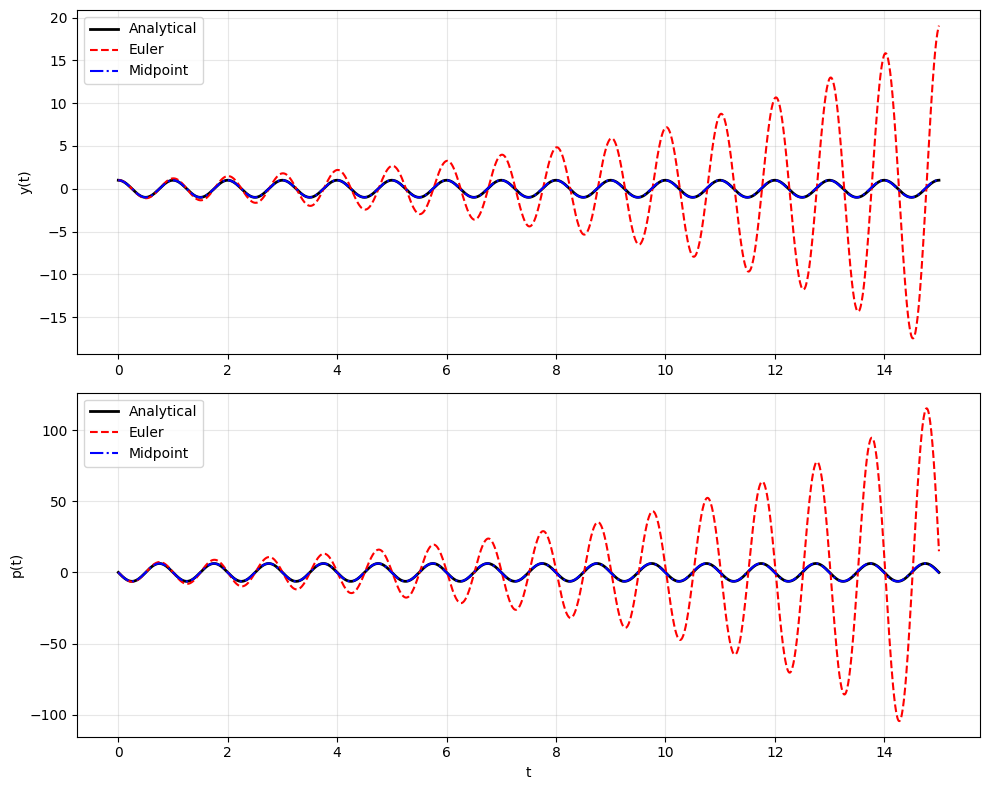

In [5]:
def rhs_q2(t, state):
    return np.array([state[1], -4 * np.pi**2 * state[0]])

step_size = 0.01
init_state = np.array([1.0, 0.0])

time_grid = np.arange(t_start, t_end + step_size, step_size)

sol_euler = solve_ode(euler, rhs_q2, init_state, time_grid, step_size)
sol_midpt = solve_ode(midpoint, rhs_q2, init_state, time_grid, step_size)

y_analytical = np.cos(2 * np.pi * time_grid)
p_analytical = -2 * np.pi * np.sin(2 * np.pi * time_grid)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(time_grid, y_analytical, 'k-', linewidth=2, label='Analytical')
axes[0].plot(time_grid, sol_euler[:, 0], 'r--', label='Euler')
axes[0].plot(time_grid, sol_midpt[:, 0], 'b-.', label='Midpoint')
axes[0].set_ylabel('y(t)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(time_grid, p_analytical, 'k-', linewidth=2, label='Analytical')
axes[1].plot(time_grid, sol_euler[:, 1], 'r--', label='Euler')
axes[1].plot(time_grid, sol_midpt[:, 1], 'b-.', label='Midpoint')
axes[1].set_xlabel('t')
axes[1].set_ylabel('p(t)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

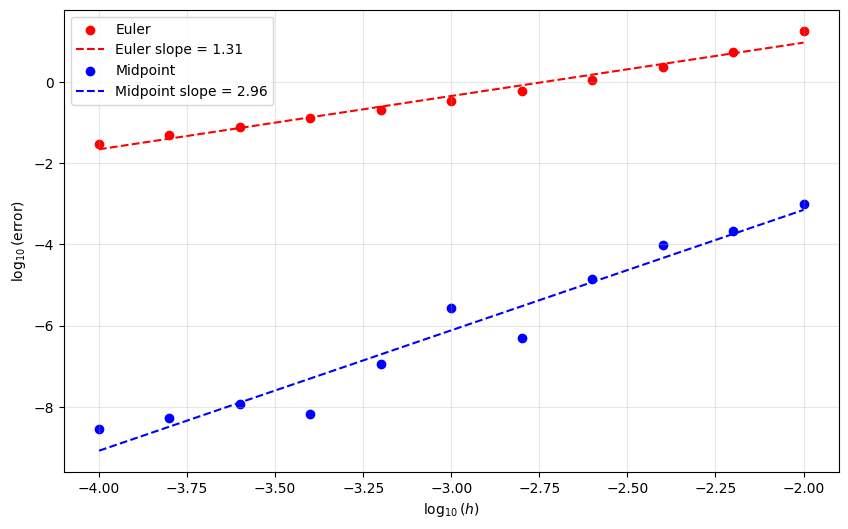

In [6]:
err_euler = []
err_midpt = []

for h in step_sizes:
    t_vals = np.arange(t_start, t_end + h, h)
    y_euler = solve_ode(euler, rhs_q2, init_state, t_vals, h)
    y_midpt = solve_ode(midpoint, rhs_q2, init_state, t_vals, h)
    exact_y = np.cos(2 * np.pi * t_vals[-1])
    err_euler.append(abs(y_euler[-1, 0] - exact_y))
    err_midpt.append(abs(y_midpt[-1, 0] - exact_y))

err_euler = np.array(err_euler)
err_midpt = np.array(err_midpt)

log_err_e = np.log10(err_euler)
log_err_m = np.log10(err_midpt)

fit_e, _ = curve_fit(fit_line, log_steps, log_err_e)
fit_m, _ = curve_fit(fit_line, log_steps, log_err_m)

plt.figure(figsize=(10, 6))
plt.scatter(log_steps, log_err_e, label="Euler", color='red')
plt.plot(log_steps, fit_line(log_steps, *fit_e), 'r--', label=f"Euler slope = {fit_e[0]:.2f}")
plt.scatter(log_steps, log_err_m, label="Midpoint", color='blue')
plt.plot(log_steps, fit_line(log_steps, *fit_m), 'b--', label=f"Midpoint slope = {fit_m[0]:.2f}")
plt.xlabel(r'$\log_{10}(h)$')
plt.ylabel(r'$\log_{10}$(error)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()